# HyperParameters Optimization, 2 steps Neural Network

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions2 import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [3]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_LF = "../DATA/reaction_diffusion_LF_46_d75.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

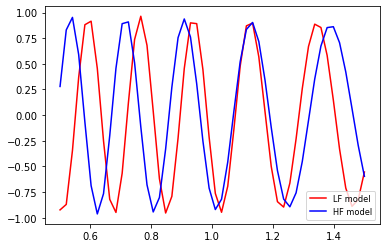

In [4]:
plt.figure()
plt.plot(reaction_LF_test, U_LF_test[
    :,
     - 1,
    12,12
], "r-", linewidth=1.5, label="LF model")
plt.plot(
    reaction_HF_test,
    U_HF_test[
    :,
     - 1,
    44,44
],
    "b-",
    markersize=7,
    label="HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

In [5]:
########################     NORMALIZATION  #########################
# Input
reaction_LF_test = normalization(reaction_LF_test)
reaction_HF_test = normalization(reaction_HF_test)
U_LF_test=U_LF_test[
    :,
     - 1,
    12,12
]
U_HF_test=U_HF_test[
    :,
     - 1,
    44,44
]
U_LF_test=normalization(U_LF_test)
U_HF_test=normalization(U_HF_test)


In [6]:
#########################     TRAIN SET      ##########################
NepoLF = 4000  # number of epochs for first NN: NN_LF
NepoHF = 8000  # number of epochs for second NN: NN_HF
Nlf = 100
n_HF=200


In [7]:
noise_stddev2 = 0.01       # value?
noise2 = np.random.normal(0, noise_stddev2, U_HF_test.shape[0])
noise_stddev3 = 0.005       # value?
noise3 = np.random.normal(0, noise_stddev3, U_HF_test.shape[0])
U_HF_noise2 = U_HF_test + noise2
U_HF_noise3 = U_HF_test + noise3

noise_stddev4 = 0.02       # value?
noise4 = np.random.normal(0, noise_stddev4, U_HF_test.shape[0])
noise_stddev5 = 0.005       # value?
noise5 = np.random.normal(0, noise_stddev5, U_HF_test.shape[0])
U_HF_noise4 = U_HF_test + noise4
U_HF_noise5 = U_HF_test + noise5



U_HF_test = np.concatenate((U_HF_test, U_HF_noise2,U_HF_noise3,U_HF_noise4,U_HF_noise5),axis=0)


noise_stddev2 = 0.005       # value?
noise2 = np.random.normal(0, noise_stddev2, reaction_HF_test.shape)
noise_stddev3 = 0.003       # value?
noise3 = np.random.normal(0, noise_stddev3, reaction_HF_test.shape)
reaction_HF_noise2 = reaction_HF_test + noise2
reaction_HF_noise3 = reaction_HF_test + noise3

noise_stddev4 = 0.01       # value?
noise4 = np.random.normal(0, noise_stddev4, reaction_HF_test.shape)
noise_stddev5 = 0.003       # value?
noise5 = np.random.normal(0, noise_stddev5, reaction_HF_test.shape)
reaction_HF_noise4 = reaction_HF_test + noise4
reaction_HF_noise5 = reaction_HF_test + noise5

reaction_HF_test = np.concatenate((reaction_HF_test, reaction_HF_noise2,reaction_HF_noise3,reaction_HF_noise4,reaction_HF_noise5))


In [8]:
noise_stddev2 = 0.02       # value?
noise2 = np.random.normal(0, noise_stddev2, U_LF_test.shape)
noise_stddev3 = 0.01       # value?
noise3 = np.random.normal(0, noise_stddev3, U_LF_test.shape)
U_LF_noise2 = U_LF_test + noise2
U_LF_noise3 = U_LF_test + noise3
noise_stddev4 = 0.02       # value?
noise4 = np.random.normal(0, noise_stddev4, U_LF_test.shape)
noise_stddev5 = 0.01       # value?
noise5 = np.random.normal(0, noise_stddev5, U_LF_test.shape)
U_LF_noise4 = U_LF_test + noise4
U_LF_noise5 = U_LF_test + noise5
noise_stddev6 = 0.02       # value?
noise6 = np.random.normal(0, noise_stddev6, U_LF_test.shape)
U_LF_noise6 = U_LF_test + noise6
noise_stddev7 = 0.01       # value?
noise7 = np.random.normal(0, noise_stddev7, U_LF_test.shape)
U_LF_noise7 = U_LF_test + noise7

U_LF_test = np.concatenate((U_LF_test, U_LF_noise2,U_LF_noise3,U_LF_noise4,U_LF_noise5,U_LF_noise6,U_LF_noise7),axis=0)

noise_stddev2 = 0.01       # value?
noise2 = np.random.normal(0, noise_stddev2, reaction_LF_test.shape)
noise_stddev3 = 0.005       # value?
noise3 = np.random.normal(0, noise_stddev3, reaction_LF_test.shape)
reaction_LF_noise2 = reaction_LF_test + noise2
reaction_LF_noise3 = reaction_LF_test + noise3
noise_stddev4 = 0.01       # value?
noise4 = np.random.normal(0, noise_stddev4, reaction_LF_test.shape)
noise_stddev5 = 0.005       # value?
noise5 = np.random.normal(0, noise_stddev5, reaction_LF_test.shape)
reaction_LF_noise4 = reaction_LF_test + noise4
reaction_LF_noise5 = reaction_LF_test + noise5
noise_stddev6 = 0.005       # value?
noise6 = np.random.normal(0, noise_stddev6, reaction_LF_test.shape)
reaction_LF_noise6 = reaction_LF_test + noise6
noise_stddev7 = 0.01       # value?
noise7 = np.random.normal(0, noise_stddev7, reaction_LF_test.shape)
reaction_LF_noise7 = reaction_LF_test + noise7

reaction_LF_test = np.concatenate((reaction_LF_test, reaction_LF_noise2,reaction_LF_noise3,reaction_LF_noise4,reaction_LF_noise5,reaction_LF_noise6,reaction_LF_noise7))




In [9]:
permutation = np.random.permutation(len(reaction_LF_test))
reaction_LF = reaction_LF_test[permutation][0:Nlf]
U_LF = U_LF_test[permutation][0:Nlf]

permutation = np.random.permutation(len(reaction_HF_test))
reaction_HF = reaction_HF_test[permutation][0:n_HF]
U_HF = U_HF_test[permutation][0:n_HF]

reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]

reaction_HF=np.c_[reaction_HF, np.abs(np.sin(5*np.pi*reaction_HF[:, 0]-5*np.pi/6))]
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]


# Neural Network
## Low Fidelity NN 

In [10]:
##########################       FIRST NN: NN_LF     ##########################
K.clear_session()
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
}  # obtained

modelLF = getModel(bestLF_params, "LF")
histLF = modelLF.fit(
    reaction_LF, U_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
)
print("LF NN done")

ULF = modelLF.predict(reaction_LF_test)
print("\nLF Model:")

test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
print(f"Test MSE: {test_mse}")

r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
    np.square(U_LF_test - np.mean(U_LF_test))
)
print(f"R^2: {r_2}")

LF NN done
11/11 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.07466945500237664
R^2: 0.39632401042822185


11/11 [==============================] - 0s 3ms/step


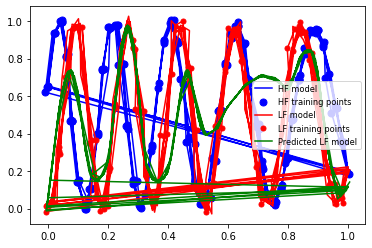

In [11]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(reaction_HF_test[:,0], U_HF_test, "b-", linewidth=1.5, label="HF model")
plt.plot(
    reaction_HF[:,0],
    U_HF,
    "bo",
    markersize=7,
    label="HF training points",
)
plt.plot(reaction_LF_test[:,0], U_LF_test, "r-", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[:,0],
    U_LF,
    "ro",
    markersize=5,
    label="LF training points",
)
plt.plot(
    reaction_LF_test[:,0],
    modelLF.predict(reaction_LF_test),
    "g-",
    label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

## High Fidelity NN

In [12]:
print(f"\n-------  #HF data = {n_HF}  -------")
start = perf_counter()

##########################    SECOND NN: NN_HF    ##########################
reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
reaction_test_in = np.concatenate(
                    (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
                )    # <- TEST INPUT for the second NN: NN_HF

reaction_train_help = modelLF.predict(reaction_HF)[:, 0]  # f_LF(mu_hf_train)
reaction_final = np.concatenate(
                    (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

name = "2step"



-------  #HF data = 200  -------
7/7 [==============================] - 0s 3ms/step


### HPO

In [13]:
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 15

K.clear_session()
bayes_trials = Trials()
opt_list = ["Adam", "Adamax"]
kernel_list = ["uniform", "glorot_uniform"]
aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
space = {
    "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
    "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(100)),
    "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
    "kernel_init": hp.choice("kernel_init", kernel_list),
    "opt": hp.choice("opt", opt_list),
}


def objective(params):
    K.clear_session()
    CVres = kCrossVal(n_HF, NepoHF, reaction_final, U_HF, params, name)

    # mse, r_squared = calculate_metrics(Nhf, NepoHF, mu_final, U_hf_train, params, name)   # ADDED

    # return {'loss': CVres, 'mse': mse, 'r_squared': r_squared, 'params': params, 'status': STATUS_OK}
    return {"loss": CVres, "params": params, "status": STATUS_OK}


best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVAL,
    trials=bayes_trials,
)

transfBestparam(best_params, aux_dic)
print(best_params)


  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]

1/1 [==============================] - 0s 63ms/step  

1/1 [==============================] - 0s 28ms/step  

1/1 [==============================] - 0s 33ms/step  

1/1 [==============================] - 0s 25ms/step  

1/1 [==============================] - 0s 14ms/step  

1/1 [==============================] - 0s 17ms/step  

1/1 [==============================] - 0s 15ms/step  

1/1 [==============================] - 0s 27ms/step  

1/1 [==============================] - 0s 29ms/step  

1/1 [==============================] - 0s 28ms/step  

1/1 [==============================] - 0s 27ms/step  

1/1 [==============================] - 0s 27ms/step  

1/1 [==============================] - 0s 26ms/step  

1/1 [==============================] - 0s 26ms/step  

1/1 [==============================] - 0s 28ms/step  

1/1 [==============================] - 0s 27ms/step  

1/1 [==============================] - 0s 28ms/step  

1/1 [==============================] - 0s 27ms/step  

1/1 [=====

KeyboardInterrupt: 

## Training & Predictions

2/2 [==============================] - 0s 16ms/step
Elapsed time:  2632.874102199916

HF Model:
Test MSE: 0.1302255842594904
R^2: -0.1504150151817889
Number of HF data:  20
2/2 [==============================] - 0s 16ms/step


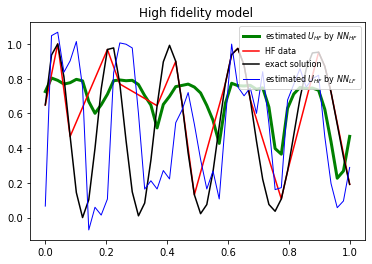

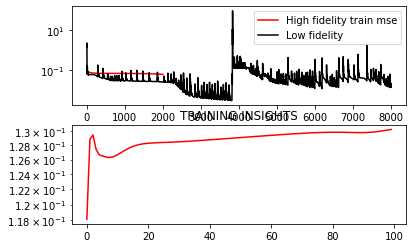

In [ ]:
####################    NN_HF training and PREDICTION    #######################
finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters
hist = finalModel.fit(
    reaction_final,
    U_HF,
    validation_data=(reaction_test_in, U_HF_test),
    epochs=NepoHF,
    batch_size=n_HF,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_test_in)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")

# print("Number of basis functions: ", int(Nlf_models[m]))
print("Number of HF data: ", n_HF)

####################    HF GRAPHS    #######################
plt.figure()
plt.plot(
    reaction_HF_test[:,0],
    UHF,
    "g-",
    label="estimated $U_{HF}$ by $NN_{HF}$",
    linewidth=3,
)  # estimated values of u_HF by third NN
order=np.argsort(reaction_HF[:,0])
plt.plot(reaction_HF[order,0], U_HF[order], "r-", label="HF data")  # high fidelity data
plt.plot(
    reaction_HF_test[:,0], U_HF_test, "k-", label="exact solution"
)  # exact solution
plt.plot(
    reaction_HF_test[:,0],
    modelLF.predict(reaction_HF_test),
    "b-",
    label="estimated $U_{HF}$ by $NN_{LF}$",
    linewidth=1,
)
plt.title("High fidelity model ")
plt.legend(loc=1, prop={"size": 8})
plt.show()

####################    TRAINING INSIGHTS    #######################
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(hist.history["mse"], color="red", label="High fidelity train mse")
plt.plot(histLF.history["mse"], color="black", label="Low fidelity")
plt.legend()
plt.yscale("log")
plt.subplot(2, 1, 2)
plt.plot(hist.history["val_mse"], color="red")
plt.yscale("log")
plt.title("TRAINING INSIGHTS")
plt.show()